# 1. Carga y preparación de datos

In [23]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [13]:
diabetes = load_diabetes(as_frame=True)

In [15]:
#Mostramos los datos
df_diabetes = diabetes.frame
df_diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [16]:
df_diabetes.isna().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [39]:
# Variable dependiente e independiente
x = df_diabetes[['bmi']]
y = df_diabetes['target']

In [53]:
#Dividir los datos en entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3,  random_state=0)

# 2. Implementar el modelo de regresión lineal

In [54]:
#Implementar el modelo de regresión lineal
regressor = LinearRegression()
regressor.fit(x_train, y_train)
y_pred = regressor.predict(x_train)

# 3. Evaluar el modelo

In [55]:
# Evaluar el modelo
from sklearn.metrics import mean_squared_error, r2_score

print('Coefficients: \n', regressor.coef_)
print('Independent term: \n', regressor.intercept_)
print('Mean squared error: %.2f' % mean_squared_error(y_train, y_pred))

Coefficients: 
 [1013.17358257]
Independent term: 
 153.43509039227231
Mean squared error: 3892.72


In [56]:
print(regressor.score(x_test, y_test))
print('Variance score: %.2f' % r2_score(y_train, y_pred))

0.23132831307953783
Variance score: 0.38


# 4. Graficar los resultados

Text(0.5, 0.98, 'Linear Regression Model')

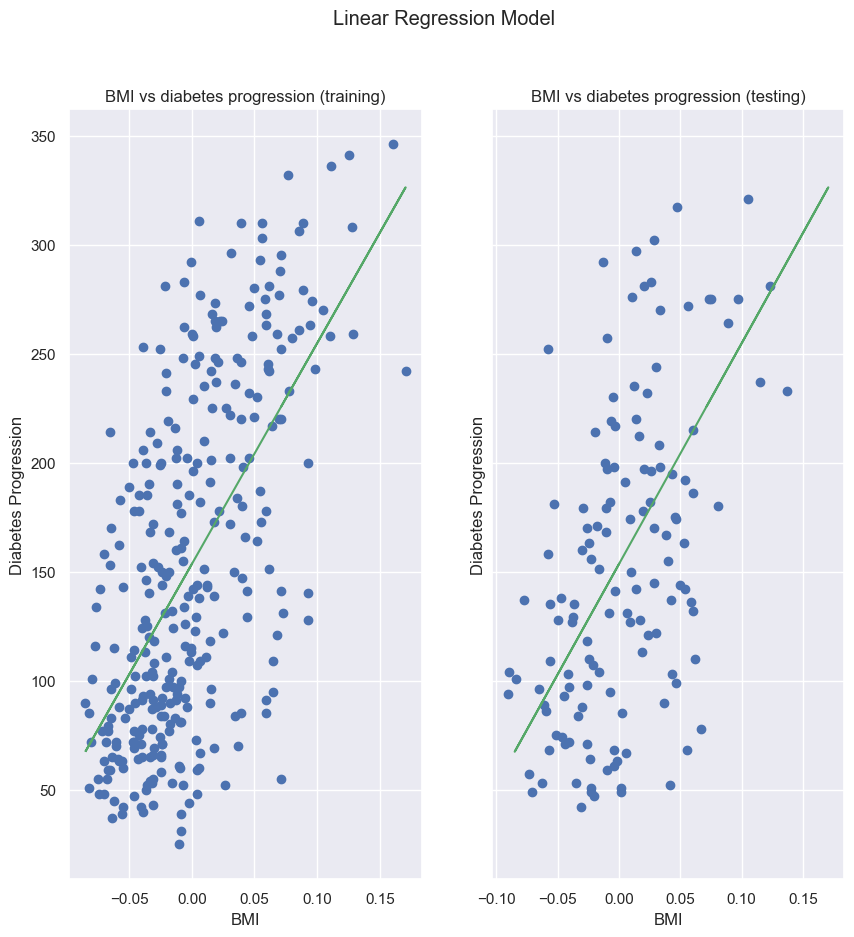

In [57]:
sns.set_theme()
fig, ax = plt.subplots(1, 2, figsize=(10,10), sharey=True)
ax[0].scatter(x_train, y_train)
ax[0].plot(x_train, regressor.predict(x_train), c='g')
ax[0].set_title('BMI vs diabetes progression (training)')
ax[0].set_xlabel('BMI')
ax[0].set_ylabel('Diabetes Progression')
ax[1].scatter(x_test, y_test)
ax[1].plot(x_train, regressor.predict(x_train), c='g')
ax[1].set_title('BMI vs diabetes progression (testing)')
ax[1].set_xlabel('BMI')
ax[1].set_ylabel('Diabetes Progression')
plt.suptitle('Linear Regression Model')

# 5. Conclusión
En general, a mayor BMI, mayor es la progresión estimada de la enfermedad. Sin embargo, la varianza obtenida indica que el modelo solo explica un 38% de la variabilidad de la progresión de la diabetes. Por lo tanto, para mejorar el desempeño del modelo sería recomendable incluir más variables independientes y considerar modelos más complejos.